# **DATA**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
file = "/content/drive/MyDrive/Colab_Notebooks/adult.csv"
df = pd.read_csv(file)

In [ ]:
df.head(20)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


# **EDA (BAB 4 A)**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
target_counts = df['income'].value_counts()
target_percent = df['income'].value_counts(normalize=True) * 100

print("Distribusi Kelas:")
print(target_counts)
print("\nPersentase Tiap Kelas:")
print(target_percent)

Distribusi Kelas:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Persentase Tiap Kelas:
income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


<ipython-input-8-3feff35cc7c2>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df, palette='Set2')


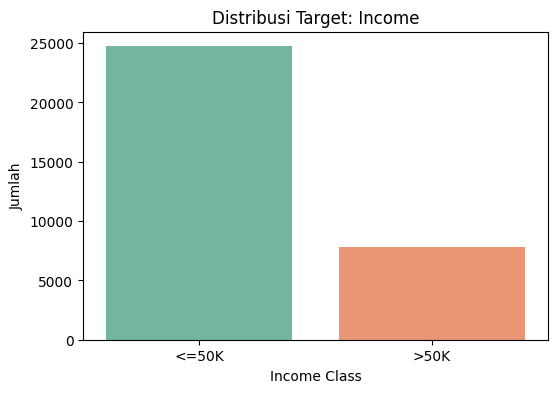

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='income', data=df, palette='Set2')
plt.title('Distribusi Target: Income')
plt.xlabel('Income Class')
plt.ylabel('Jumlah')
plt.show()

In [ ]:
y1 = df["income"]
X1 = df.drop(columns="income")

In [ ]:
cat_cols1 = X1.select_dtypes("object").columns
num_cols1 = X1.select_dtypes(exclude="object").columns

In [ ]:
print(cat_cols1)
print(num_cols1)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')
Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')


In [ ]:
def plot_top_categories(df, col, top_n=20):
    plt.figure(figsize=(8,4))
    vc = df[col].value_counts().head(top_n)
    sns.barplot(x=vc.values, y=vc.index, palette='viridis')
    plt.title(f'Top {top_n} kategori pada kolom: {col}')
    plt.xlabel('Jumlah')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

<ipython-input-12-424becbbdad1>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='viridis')


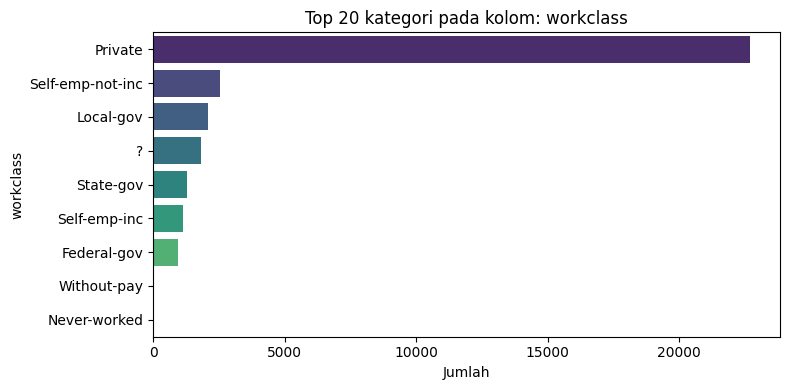

<ipython-input-12-424becbbdad1>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='viridis')


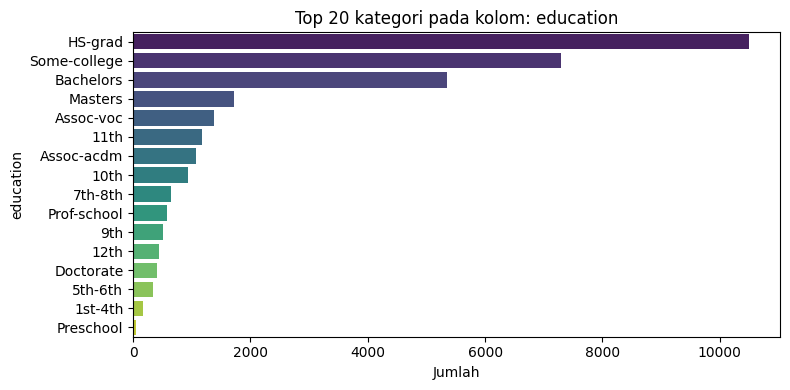

<ipython-input-12-424becbbdad1>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='viridis')


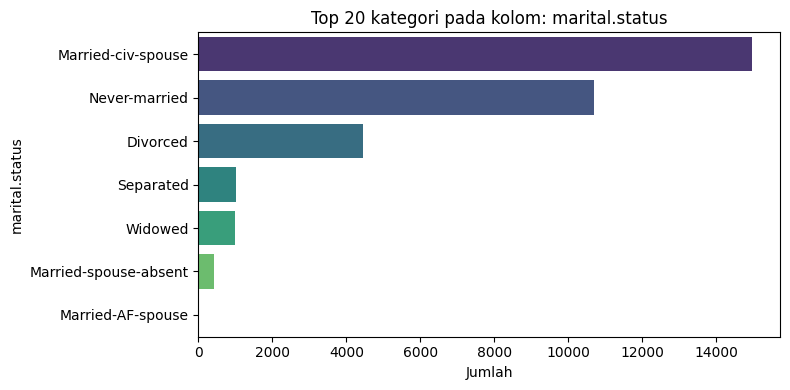

<ipython-input-12-424becbbdad1>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='viridis')


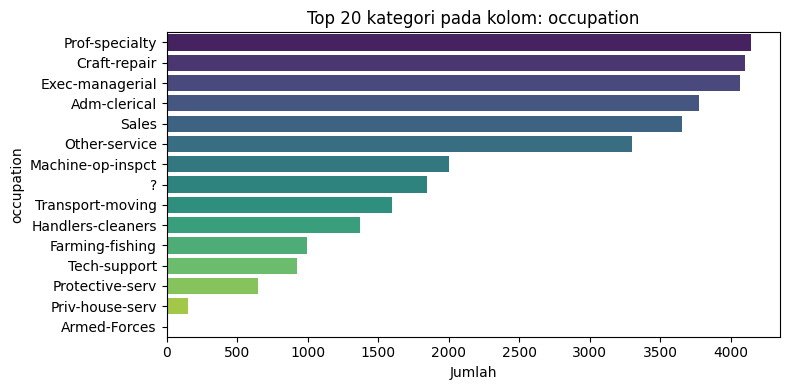

<ipython-input-12-424becbbdad1>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='viridis')


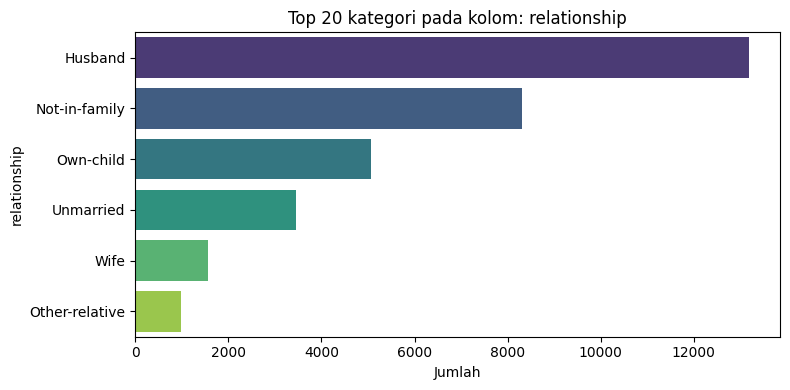

<ipython-input-12-424becbbdad1>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='viridis')


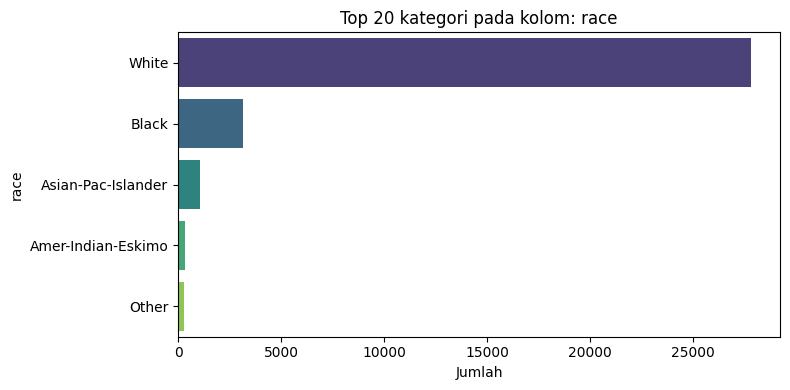

<ipython-input-12-424becbbdad1>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='viridis')


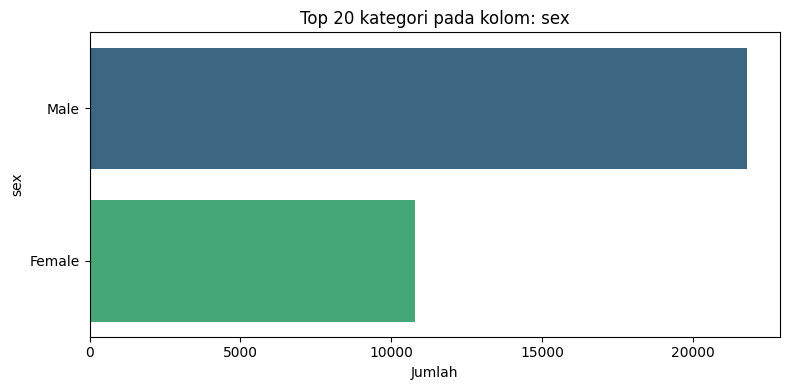

<ipython-input-12-424becbbdad1>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='viridis')


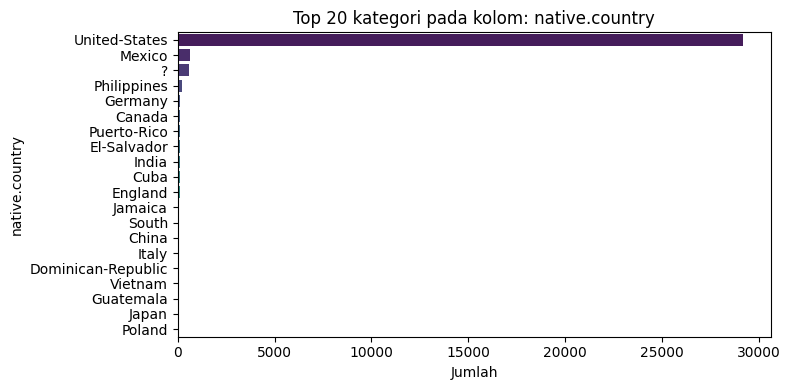

In [ ]:
for col in cat_cols1:
    plot_top_categories(df, col)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df.replace('?', np.nan, inplace=True)

In [ ]:
missing_counts = df.isna().sum()
pct_missing = df.isna().mean() * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": pct_missing
})

missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing %", ascending=False)
print(missing_df)

                Missing Count  Missing %
occupation               1843   5.660146
workclass                1836   5.638647
native.country            583   1.790486


In [ ]:
df[['capital.gain', 'capital.loss', 'hours.per.week']].describe().T

,count,mean,std,min,25%,50%,75%,max
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [ ]:
outlier_jamkerja = 90
hitung_outlier = (df['hours.per.week'] > outlier_jamkerja).sum()
persen_outlier = 100 * hitung_outlier / len(df)

print(f"Kerja > {outlier_jamkerja} jam/minggu: {hitung_outlier} ({persen_outlier:.2f}%)")

Kerja > 90 jam/minggu: 110 (0.34%)


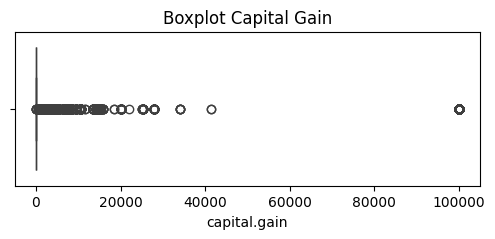

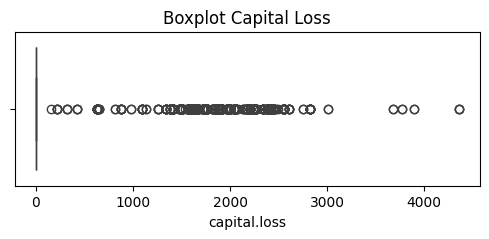

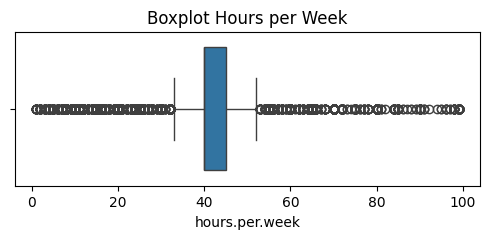

In [ ]:
# Capital Gain
plt.figure(figsize=(6,2))
sns.boxplot(x=df['capital.gain'])
plt.title("Boxplot Capital Gain")
plt.show()

# Capital Loss
plt.figure(figsize=(6,2))
sns.boxplot(x=df['capital.loss'])
plt.title("Boxplot Capital Loss")
plt.show()

# Hours per Week
plt.figure(figsize=(6,2))
sns.boxplot(x=df['hours.per.week'])
plt.title("Boxplot Hours per Week")
plt.show()

**BIVARIAT**

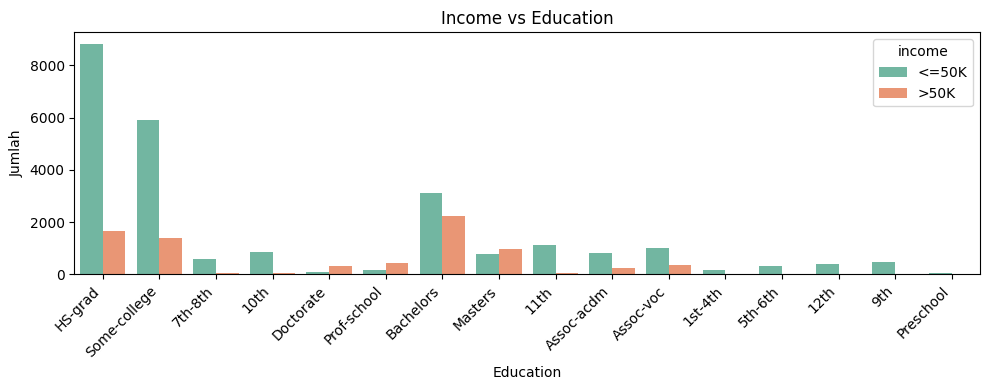

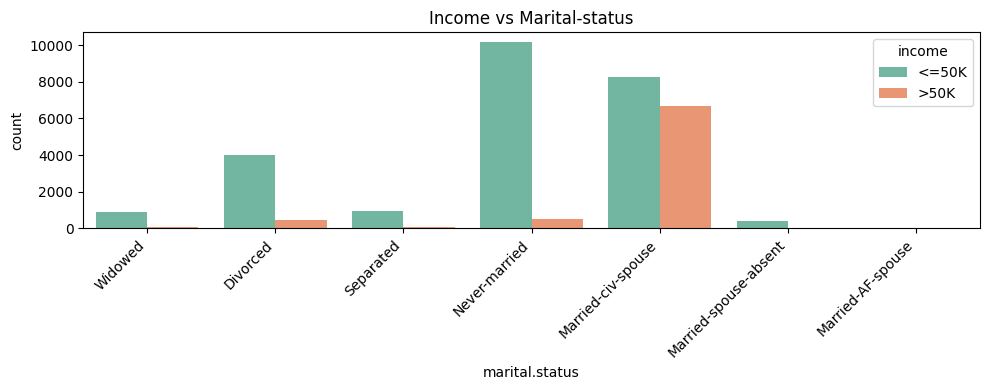

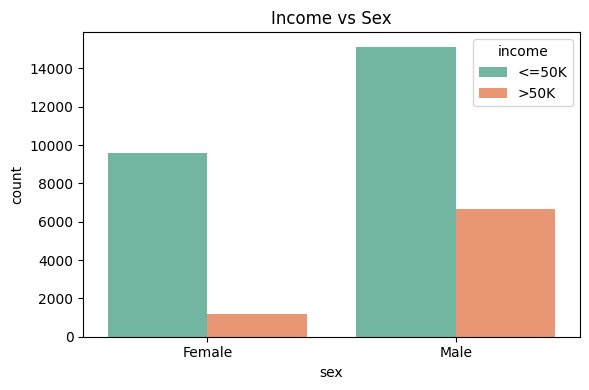

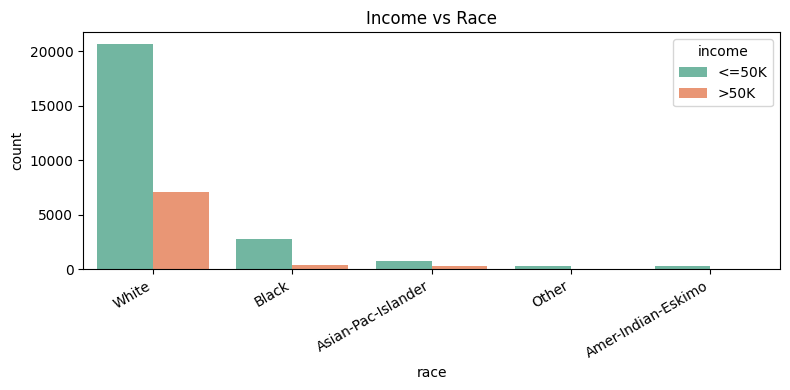

In [ ]:
# Education vs Income
plt.figure(figsize=(10,4))
sns.countplot(x='education', hue='income', data=df, palette='Set2')
plt.title('Income vs Education')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Education')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

# Marital Status vs Income
plt.figure(figsize=(10,4))
sns.countplot(x='marital.status', hue='income', data=df, palette='Set2')
plt.title('Income vs Marital-status')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Sex vs Income
plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='income', data=df, palette='Set2')
plt.title('Income vs Sex')
plt.tight_layout()
plt.show()

# Race vs Income
plt.figure(figsize=(8,4))
sns.countplot(x='race', hue='income', data=df, palette='Set2')
plt.title('Income vs Race')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

<ipython-input-21-aa0389fff930>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='income', y='age', data=df, palette='Set3', cut=0, bw=.2)
<ipython-input-21-aa0389fff930>:3: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(x='income', y='age', data=df, palette='Set3', cut=0, bw=.2)


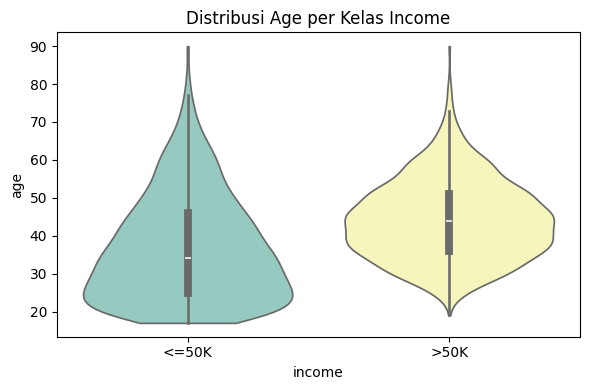

<ipython-input-21-aa0389fff930>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='income', y='hours.per.week', data=df, palette='Set3', cut=0, bw=.2)
<ipython-input-21-aa0389fff930>:10: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(x='income', y='hours.per.week', data=df, palette='Set3', cut=0, bw=.2)


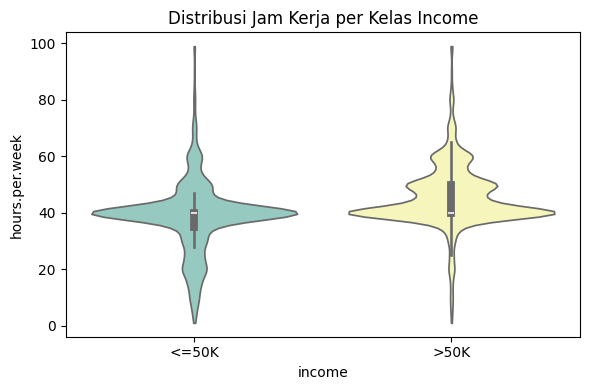

In [ ]:
# Age vs Income
plt.figure(figsize=(6,4))
sns.violinplot(x='income', y='age', data=df, palette='Set3', cut=0, bw=.2)
plt.title('Distribusi Age per Kelas Income')
plt.tight_layout()
plt.show()

# Hours per Week vs Income
plt.figure(figsize=(6,4))
sns.violinplot(x='income', y='hours.per.week', data=df, palette='Set3', cut=0, bw=.2)
plt.title('Distribusi Jam Kerja per Kelas Income')
plt.tight_layout()
plt.show()

**WINSORIZE LOG1P**

In [ ]:
df_clean = df.copy()

In [ ]:
cg_p99 = df_clean['capital.gain'].quantile(0.99)
cl_p99 = df_clean['capital.loss'].quantile(0.99)
df_clean['capital.gain.clip'] = np.clip(df_clean['capital.gain'], 0, cg_p99)
df_clean['capital.loss.clip'] = np.clip(df_clean['capital.loss'], 0, cl_p99)
df_clean['capital.gain.log']  = np.log1p(df_clean['capital.gain.clip'])
df_clean['capital.loss.log']  = np.log1p(df_clean['capital.loss.clip'])

**KORELASI NUMERIK**

In [ ]:
df_clean['income.bin'] = (df_clean['income'] == '>50K').astype(int)

In [ ]:
corr_cols = [
    'age',
    'education.num',
    'hours.per.week',
    'capital.gain.log',
    'capital.loss.log',
    'income.bin'
]

In [ ]:
corr_matrix = df_clean[corr_cols].corr(method='pearson')

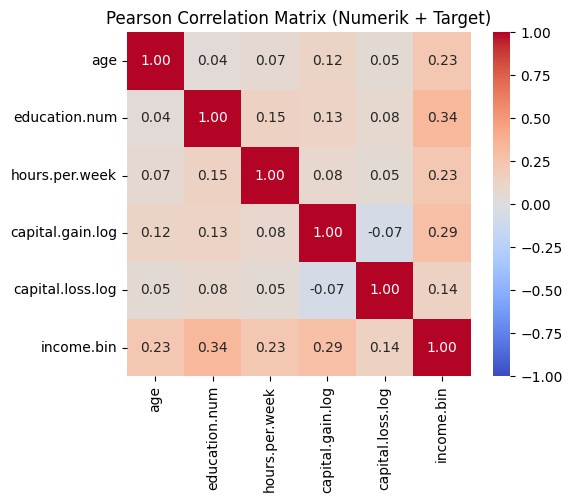

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Pearson Correlation Matrix (Numerik + Target)")
plt.tight_layout()
plt.show()

**Korelasi Kategorik Paling Berpengaruh**

In [ ]:
y = df["income"]
X = df.drop(columns="income")

In [ ]:
cat_cols = X.select_dtypes("object").columns
num_cols = X.select_dtypes(exclude="object").columns

In [ ]:
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat  = ohe.fit_transform(df[cat_cols])
y      = (df['income'] == '>50K').astype(int).values

chi_vals, p_vals = chi2(X_cat, y)
chi_df = pd.DataFrame({
    'feature': ohe.get_feature_names_out(cat_cols),
    'chi2':    chi_vals,
    'p_value': p_vals
}).sort_values('chi2', ascending=False)

mi_vals = mutual_info_classif(X_cat, y, discrete_features=True, random_state=42)
mi_df = pd.DataFrame({
    'feature': ohe.get_feature_names_out(cat_cols),
    'MI':      mi_vals
}).sort_values('MI', ascending=False)

print("\nTop 10 kategori menurut χ²")
print(chi_df.head(10))

print("\nTop 10 kategori menurut Mutual Information")
print(mi_df.head(10))



Top 10 kategori menurut χ²
                              feature         chi2        p_value
27  marital.status_Married-civ-spouse  3477.515877   0.000000e+00
47               relationship_Husband  3114.941546   0.000000e+00
29       marital.status_Never-married  2218.521977   0.000000e+00
50             relationship_Own-child  1435.873016   0.000000e+00
35         occupation_Exec-managerial  1315.482632  4.882518e-288
58                         sex_Female  1016.447400  4.777743e-223
41          occupation_Prof-specialty   981.835068  1.594790e-215
21                  education_Masters   939.775218  2.214989e-206
18                education_Bachelors   886.235182  9.641670e-195
48         relationship_Not-in-family   861.846218  1.932833e-189

Top 10 kategori menurut Mutual Information
                              feature        MI
27  marital.status_Married-civ-spouse  0.105432
47               relationship_Husband  0.080877
29       marital.status_Never-married  0.061951
50        

In [ ]:
from IPython.display import display

# χ²
top_chi = (
    chi_df.nlargest(10, "chi2")[["feature", "chi2", "p_value"]]
           .reset_index(drop=True)
           .assign(rank=lambda d: d.index + 1)
           .set_index("rank")
)
# MI
top_mi = (
    mi_df.nlargest(10, "MI")[["feature", "MI"]]
          .reset_index(drop=True)
          .assign(rank=lambda d: d.index + 1)
          .set_index("rank")
)
merged = (
    top_chi.rename(columns={"feature": "Feature_χ²"})
            .join(top_mi.rename(columns={"feature": "Feature_MI"}), how="outer")
)

display(
    merged.style.format({"chi2": "{:,.0f}", "p_value": "{:.1e}", "MI": "{:.3f}"})
          .set_caption("Top 10 Fitur Kategorik menurut χ² dan Mutual Information")
)

,Feature_χ²,chi2,p_value,Feature_MI,MI
rank,,,,,
1,marital.status_Married-civ-spouse,"3,478",0.0e+00,marital.status_Married-civ-spouse,0.105
2,relationship_Husband,"3,115",0.0e+00,relationship_Husband,0.081
3,marital.status_Never-married,"2,219",0.0e+00,marital.status_Never-married,0.062
4,relationship_Own-child,"1,436",0.0e+00,relationship_Own-child,0.038
5,occupation_Exec-managerial,"1,315",4.9e-288,sex_Male,0.026
6,sex_Female,"1,016",4.8e-223,sex_Female,0.026
7,occupation_Prof-specialty,982,1.6e-215,occupation_Exec-managerial,0.020
8,education_Masters,940,2.2e-206,relationship_Not-in-family,0.020
9,education_Bachelors,886,9.6e-195,occupation_Other-service,0.016


# **PRE-PROCESSING DATA (BAB 4 B)**

In [ ]:
df.shape

(30162, 15)

In [ ]:
df.dropna(subset=['workclass','occupation','native.country'], inplace=True)

In [ ]:
df.shape

(30162, 15)

**LABEL**

In [ ]:
y = df["income"]
X = df.drop(columns="income")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
cat_cols = X.select_dtypes("object").columns
num_cols = X.select_dtypes(exclude="object").columns

In [ ]:
print(cat_cols)
print(num_cols)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')
Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')


**Pre-Processing**

In [ ]:
prep = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),("num", StandardScaler(), num_cols)], remainder="drop")

# **PRE-PROCESSING DATA 2**

In [ ]:
df_clean2 = df.copy()

In [ ]:
cg_p992 = df_clean2['capital.gain'].quantile(0.99)
cl_p992 = df_clean2['capital.loss'].quantile(0.99)
df_clean2['capital.gain.clip'] = np.clip(df_clean2['capital.gain'], 0, cg_p99)
df_clean2['capital.loss.clip'] = np.clip(df_clean2['capital.loss'], 0, cl_p99)
df_clean2['capital.gain.log']  = np.log1p(df_clean2['capital.gain.clip'])
df_clean2['capital.loss.log']  = np.log1p(df_clean2['capital.loss.clip'])

In [ ]:
print("Nilai kuantil 0.99 capital.gain:", cg_p992)
print("Nilai kuantil 0.99 capital.loss:", cl_p992)

Nilai kuantil 0.99 capital.gain: 15024.0
Nilai kuantil 0.99 capital.loss: 1980.0


In [ ]:
df_clean2.shape

(30162, 19)

In [ ]:
df_clean2.dropna(subset=['workclass','occupation','native.country'], inplace=True)

In [ ]:
df_clean2.shape

(30162, 19)

**LABEL**

In [ ]:
y2 = df_clean2['income']
X2 = df_clean2.drop(columns='income')

In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=42)

In [ ]:
cat_cols2 = X2.select_dtypes("object").columns
num_cols2 = [
    'age',
    'education.num',
    'hours.per.week',
    'capital.gain.log',
    'capital.loss.log'
]

In [ ]:
print(cat_cols2)
print(num_cols2)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')
['age', 'education.num', 'hours.per.week', 'capital.gain.log', 'capital.loss.log']


**LABEL 2**

**Pre-Processing**

In [ ]:
prep2 = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols2),("num", StandardScaler(), num_cols2)], remainder="drop")

# **MODEL BASIC (BAB 4 C)**

In [ ]:
logreg = Pipeline(steps=[
    ("prep", prep),
     ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])

In [ ]:
logreg.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object'))])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

# **MODEL BASIC 2**

In [ ]:
logreg2 = Pipeline(steps=[
    ("prep", prep2),
     ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])

In [ ]:
logreg2.fit(X_train2, y_train2)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  ['age', 'education.num',
                                                   'hours.per.week',
                                                   'capital.gain.log',
                                                   'capital.loss.log'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

# **MODEL SMOTE**

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [ ]:
pipe_smote = ImbPipeline(steps=[
    ("prep",  prep),
    ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
    ("clf",   LogisticRegression(max_iter=1000, n_jobs=-1))
])

In [ ]:
pipe_smote.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
                ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))])

# **REPORT(BAB 4 D)**

In [ ]:
pred1  = logreg.predict(X_test)
proba1 = logreg.predict_proba(X_test)[:, 1]

In [ ]:
pred2  = pipe_smote.predict(X_test)
proba2 = pipe_smote.predict_proba(X_test)[:,1]

In [ ]:
pred3  = logreg2.predict(X_test2)
proba3 = logreg2.predict_proba(X_test2)[:,1]

**BASIC2**

In [ ]:
print("Acc :", accuracy_score(y_test2, pred3))
print("F1  :", f1_score(y_test2, pred3, pos_label=">50K"))
print("AUC :", roc_auc_score(y_test2, proba3))
print("\n",  classification_report(y_test2, pred3))

Acc : 0.810044753853804
F1  : 0.6890938686923495
AUC : 0.9071619654629551

               precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      4531
        >50K       0.58      0.85      0.69      1502

    accuracy                           0.81      6033
   macro avg       0.76      0.82      0.78      6033
weighted avg       0.85      0.81      0.82      6033



**BASIC**

In [ ]:
print("Acc :", accuracy_score(y_test, pred1))
print("F1  :", f1_score(y_test, pred1, pos_label=">50K"))
print("AUC :", roc_auc_score(y_test, proba1))
print("\n",  classification_report(y_test, pred1))

Acc : 0.8183325045582629
F1  : 0.6995614035087719
AUC : 0.9135338124904306

               precision    recall  f1-score   support

       <=50K       0.94      0.81      0.87      4531
        >50K       0.59      0.85      0.70      1502

    accuracy                           0.82      6033
   macro avg       0.77      0.83      0.78      6033
weighted avg       0.86      0.82      0.83      6033



**SMOTE**

In [ ]:
print("Acc :", accuracy_score(y_test, pred2))
print("F1  :", f1_score(y_test, pred2, pos_label=">50K"))
print("AUC :", roc_auc_score(y_test, proba2))
print("\n",  classification_report(y_test, pred2))

Acc : 0.8176694845019061
F1  : 0.6984649122807017
AUC : 0.9131818944563286

               precision    recall  f1-score   support

       <=50K       0.94      0.81      0.87      4531
        >50K       0.59      0.85      0.70      1502

    accuracy                           0.82      6033
   macro avg       0.77      0.83      0.78      6033
weighted avg       0.85      0.82      0.83      6033



# **KMeans (BAB 4 C)**

In [ ]:
X_ready = prep.fit_transform(X)

In [ ]:
X_ready2 = prep2.fit_transform(X2)

In [ ]:
from scipy import sparse
print("Shape :", X_ready.shape)
print("Sparse:", sparse.issparse(X_ready))

Shape : (30162, 104)
Sparse: True


In [ ]:
X_dense = X_ready.toarray()

In [ ]:
X_dense2 = X_ready2.toarray()

In [ ]:
ks = range(2, 11)
inertia, silh = [], []

In [ ]:
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_dense)
    inertia.append(km.inertia_)
    silh.append(silhouette_score(X_dense, km.labels_))

In [ ]:
ks2 = range(2, 11)
inertia2, silh2 = [], []

In [ ]:
for k2 in ks2:
    km2 = KMeans(n_clusters=k2, n_init=10, random_state=42)
    km2.fit(X_dense2)
    inertia2.append(km2.inertia_)
    silh2.append(silhouette_score(X_dense2, km2.labels_))

# **KMeans Evaluated (BAB 4 D)**

Text(0, 0.5, 'Score')

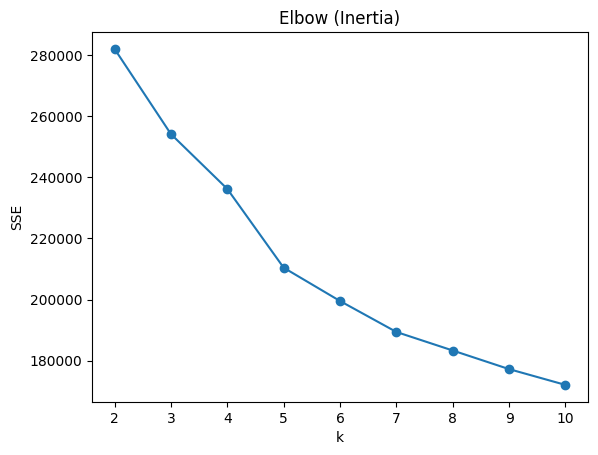

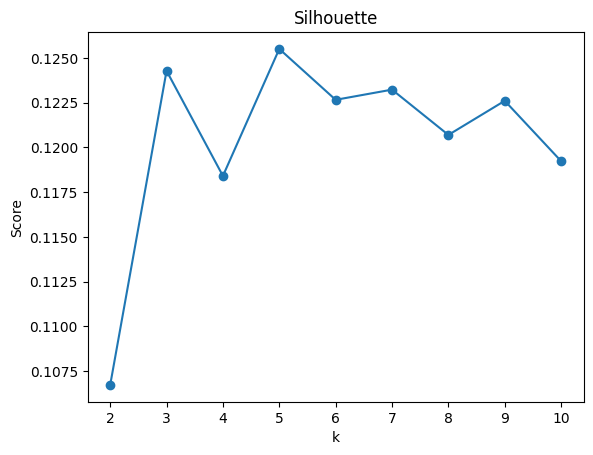

In [ ]:
plt.plot(ks, inertia, "o-"); plt.title("Elbow (Inertia)"); plt.xlabel("k"); plt.ylabel("SSE")
plt.figure()
plt.plot(ks, silh, "o-"); plt.title("Silhouette"); plt.xlabel("k"); plt.ylabel("Score")

Text(0, 0.5, 'Score')

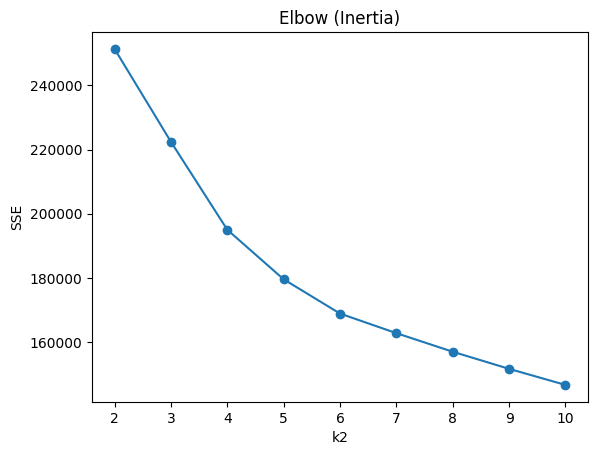

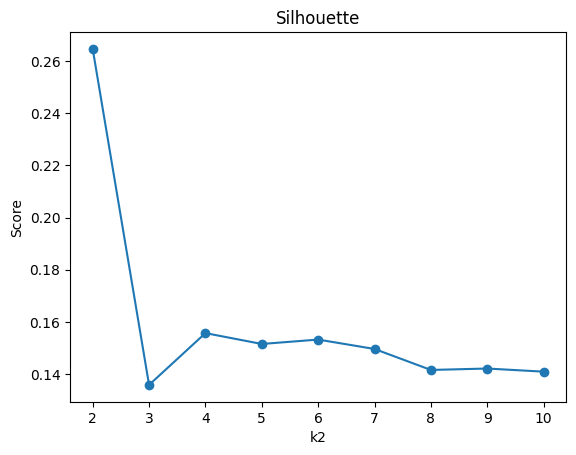

In [ ]:
plt.plot(ks2, inertia2, "o-"); plt.title("Elbow (Inertia)"); plt.xlabel("k2"); plt.ylabel("SSE")
plt.figure()
plt.plot(ks2, silh2, "o-"); plt.title("Silhouette"); plt.xlabel("k2"); plt.ylabel("Score")

In [ ]:
kluster = 4

In [ ]:
km = KMeans(n_clusters=kluster, n_init=10, random_state=42)
labels = km.fit_predict(X_dense)
df_k = df.copy()
df_k["cluster"] = labels

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_2d  = pca.fit_transform(X_dense)

In [ ]:
km2 = KMeans(n_clusters=kluster, n_init=10, random_state=42)
labels2 = km2.fit_predict(X_dense2)
df_k2 = df_clean2.copy()
df_k2["cluster"] = labels2

In [ ]:
pca2 = PCA(n_components=2, random_state=42)
X_2d_2  = pca2.fit_transform(X_dense2)

In [ ]:
cat_summary_parts = []

for col in cat_cols2:
    # modus kategori
    top_cat = (df_k2
               .groupby('cluster')[col]
               .apply(lambda s: s.value_counts(normalize=True).idxmax()))

    # persentasenya
    top_pct = (df_k2
               .groupby('cluster')[col]
               .apply(lambda s: s.value_counts(normalize=True).max()*100)
               .round(1))

    cat_summary_parts.append(
        pd.DataFrame({f'{col}_top': top_cat,
                      f'{col}_pct': top_pct})
    )

cat_summary = pd.concat(cat_summary_parts, axis=1)

# ----- distribusi income & numerik -----
dist_income  = (pd.crosstab(df_k2.cluster, df_k2.income, normalize='index')
                .rename(columns={'<=50K':'<=50K_%', '>50K':'>50K_%'}))

num_summary  = df_k2.groupby('cluster')[num_cols2].mean().round(1)

# ----- gabungkan semua -----
profile = dist_income.join(num_summary).join(cat_summary)

profile_vertikal = profile.T
profile_vertikal.index.name = 'metrik'
display(profile_vertikal)

cluster,0,1,2,3
metrik,,,,
<=50K_%,0.365048,0.962622,0.669022,0.483532
>50K_%,0.634952,0.037378,0.330978,0.516468
age,43.7,29.0,45.1,41.6
education.num,11.1,9.7,10.2,11.0
hours.per.week,44.2,35.8,44.3,43.5
capital.gain.log,8.7,0.0,0.0,0.0
capital.loss.log,0.0,0.0,0.0,7.5
workclass_top,Private,Private,Private,Private
workclass_pct,67.0,84.5,66.9,67.3


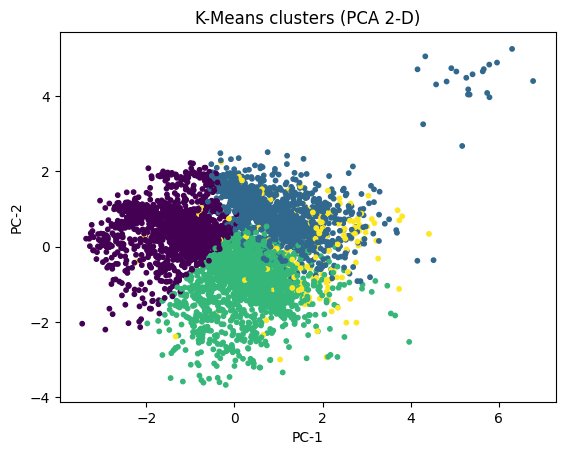

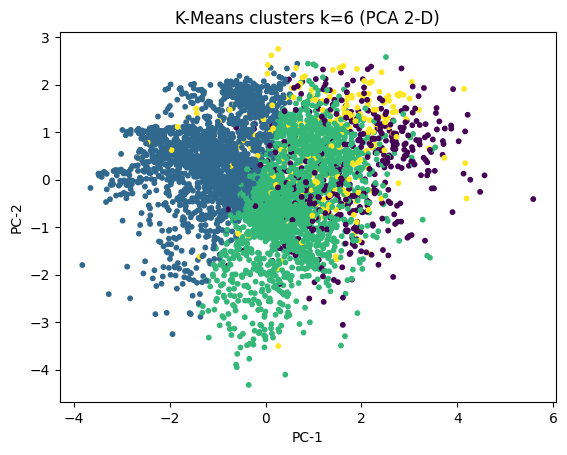

In [ ]:
idx = np.random.choice(len(X_2d), 5000, replace=False)
plt.scatter(X_2d[idx, 0], X_2d[idx, 1], c=labels[idx], s=10)
plt.title("K-Means clusters (PCA 2-D)")
plt.xlabel("PC-1"); plt.ylabel("PC-2")
plt.show()

idx2 = np.random.choice(len(X_2d_2), 5000, replace=False)
plt.scatter(X_2d_2[idx2, 0], X_2d_2[idx2, 1], c=labels2[idx2], s=10)
plt.title("K-Means clusters k=6 (PCA 2-D)")
plt.xlabel("PC-1"); plt.ylabel("PC-2")
plt.show()

# **LABELLING & MODELLING K-Means**

In [ ]:
y_cluster = labels2

In [ ]:
X_trainC, X_testC, y_trainC, y_testC = train_test_split(X2, y_cluster, test_size=0.2, stratify=y_cluster, random_state=42)

In [ ]:
pipe_cluster = Pipeline([
    ("prep", prep2),
    ("clf", LogisticRegression(max_iter=1000,
                               multi_class="multinomial",
                               class_weight="balanced"))
])

In [ ]:
pipe_cluster.fit(X_trainC, y_trainC)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  ['age', 'education.num',
                                                   'hours.per.week',
                                                   'capital.gain.log',
                                                   'capital.loss.log'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    multi_class='multinomial'))])

Accuracy : 0.997182164760484
              precision    recall  f1-score   support

           0      0.996     1.000     0.998       502
           1      0.995     0.998     0.997      2387
           2      0.999     0.995     0.997      2859
           3      1.000     1.000     1.000       285

    accuracy                          0.997      6033
   macro avg      0.997     0.998     0.998      6033
weighted avg      0.997     0.997     0.997      6033



<Axes: >

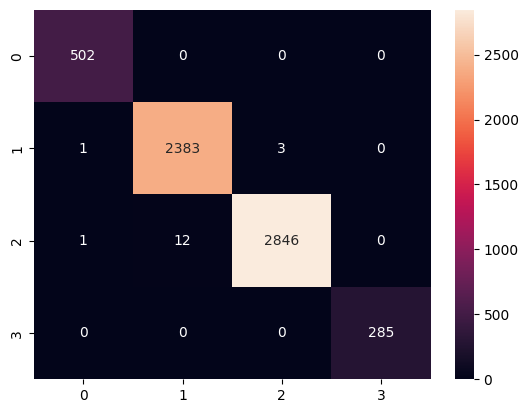

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_predC = pipe_cluster.predict(X_testC)
print("Accuracy :", accuracy_score(y_testC, y_predC))
print(classification_report(y_testC, y_predC, digits=3))
sns.heatmap(confusion_matrix(y_testC, y_predC), annot=True, fmt='d')

# **SIMPAN MODEL**

In [ ]:
import joblib
joblib.dump(logreg2, 'model_logreg_TUBES.pkl')

['model_logreg_TUBES.pkl']

In [ ]:
import joblib, sklearn
logreg2 = joblib.load("model_logreg_TUBES.pkl")
print(type(logreg2))

<class 'sklearn.pipeline.Pipeline'>


In [ ]:
from google.colab import files

files.download('model_logreg_TUBES.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **SAVE MODEL K-Means**

In [ ]:
import joblib
joblib.dump(pipe_cluster, 'model_logreg_kluster_TUBES.pkl')

['model_logreg_kluster_TUBES.pkl']

In [ ]:
import joblib, sklearn
pipe_cluster = joblib.load("model_logreg_kluster_TUBES.pkl")
print(type(pipe_cluster))

<class 'sklearn.pipeline.Pipeline'>


In [ ]:
from google.colab import files

files.download('model_logreg_kluster_TUBES.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>